# Communities & Crime (UCI) EDA

Goal: justify and document the preprocessing in `src/data/communities.py`. Each section answers one concrete question:

1. **Target** — distribution of `ViolentCrimesPerPop` (regression).
2. **Missingness** — per-column missing rate; is a **30 %** cutoff reasonable?
3. **Non-predictive columns** — why `state`, `county`, `community`, `communityname`, `fold` are dropped in stage 2.
4. **Stages 1–2** — raw loader vs `clean_communities` vs wrapper `load_communities`.
5. **Zero-variance features** — what `prepare_xy` removes before modeling.
6. **Stage 3** — `StandardScaler` after train-only median imputation (same order as `load_dataset`).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import load_communities, load_communities_raw, prepare_xy
from src.data.communities import (
    _COMMUNITIES_NON_PREDICTIVE,
    _COMMUNITIES_TARGET,
    clean_communities,
    preprocess_communities,
)
from src.data.imputation import median_impute_train
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(context="notebook", style="whitegrid")

In [2]:
X_raw, y = load_communities_raw()
print(f"stage 1 raw : X={X_raw.shape}, y={y.shape}, target={_COMMUNITIES_TARGET!r}")
print(f"non-predictive cols present: {[c for c in _COMMUNITIES_NON_PREDICTIVE if c in X_raw.columns]}")

stage 1 raw : X=(1994, 127), y=(1994,), target='ViolentCrimesPerPop'
non-predictive cols present: ['state', 'county', 'community', 'communityname', 'fold']


## 1. Target distribution

`ViolentCrimesPerPop` is normalized violent crimes per 100k population (UCI description). We use it as the regression target after stage 2.

count   1,994.000
mean        0.238
std         0.233
min         0.000
25%         0.070
50%         0.150
75%         0.330
max         1.000

missing target (stage 1): 0


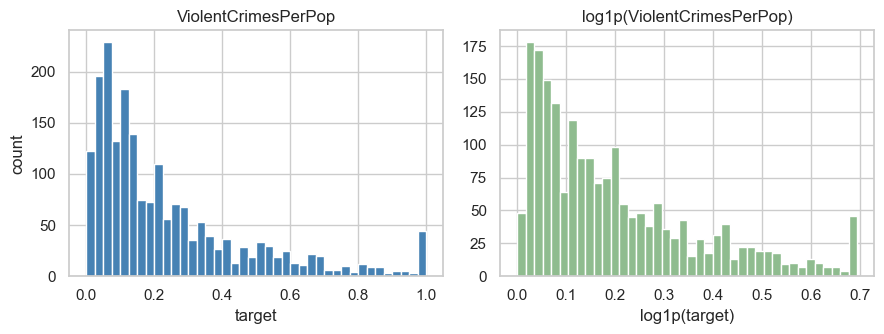

In [3]:
print(y.describe().to_string())
print(f"\nmissing target (stage 1): {y.isna().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].hist(y.dropna(), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("ViolentCrimesPerPop")
axes[0].set_xlabel("target")
axes[0].set_ylabel("count")
axes[1].hist(np.log1p(y.dropna()), bins=40, color="darkseagreen", edgecolor="white")
axes[1].set_title("log1p(ViolentCrimesPerPop)")
axes[1].set_xlabel("log1p(target)")
plt.tight_layout()
plt.show()

## 2. Missingness profile

UCI encodes missing values as `?` (already parsed as NaN in stage 1). Stage 2 drops columns with missing fraction **> 0.3** (default), which removes the LEMAS block that is missing for most communities.

We compute missingness on features **after** removing non-predictive identifiers, matching the column set used in `clean_communities` before the threshold filter.

feature cols (after dropping non-predictive): 122
0.100    100
0.200    100
0.300    100
0.400    100
0.500    100
0.700    100
0.900    122

top 15 missing fractions:
PolicBudgPerPop        0.840
PctPolicAsian          0.840
LemasSwornFT           0.840
LemasSwFTPerPop        0.840
LemasSwFTFieldOps      0.840
LemasSwFTFieldPerPop   0.840
LemasTotalReq          0.840
LemasTotReqPerPop      0.840
PolicPerPop            0.840
RacialMatchCommPol     0.840
PctPolicWhite          0.840
PctPolicBlack          0.840
PctPolicHisp           0.840
PolicReqPerOffic       0.840
PctPolicMinor          0.840


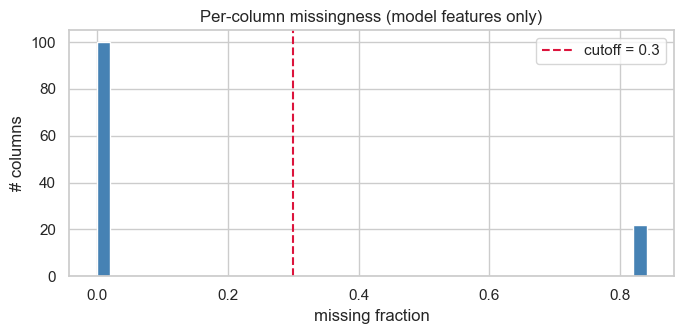

In [4]:
X_feat = X_raw.drop(columns=_COMMUNITIES_NON_PREDICTIVE, errors="ignore")
miss = X_feat.isna().mean().sort_values(ascending=False)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9]
kept = pd.Series({t: int((miss <= t).sum()) for t in thresholds}, name="cols_kept")
print(f"feature cols (after dropping non-predictive): {len(miss)}")
print(kept.to_string())
print(f"\ntop 15 missing fractions:\n{miss.head(15).to_string()}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(miss.values, bins=40, color="steelblue", edgecolor="white")
ax.axvline(0.3, color="crimson", linestyle="--", label="cutoff = 0.3")
ax.set_xlabel("missing fraction")
ax.set_ylabel("# columns")
ax.set_title("Per-column missingness (model features only)")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Same rule as clean_communities: concat target only to apply the same column mask
tmp = X_feat.copy()
tmp[_COMMUNITIES_TARGET] = y.values
mf = tmp.isna().mean()
tmp = tmp.loc[:, mf <= 0.30]
y_cut = tmp[_COMMUNITIES_TARGET]
X_cut = tmp.drop(columns=[_COMMUNITIES_TARGET])
print(f"after 30% cutoff (manual): X={X_cut.shape}, y={y_cut.shape}")

X_clean, y_clean = clean_communities(X_raw, y, drop_high_missing=0.3)
print(f"clean_communities       : X={X_clean.shape}, y={y_clean.shape}")
assert X_cut.shape == X_clean.shape and y_cut.equals(y_clean)

after 30% cutoff (manual): X=(1994, 100), y=(1994,)
clean_communities       : X=(1994, 100), y=(1994,)


## 3. Non-predictive columns

These are **identifiers or CV fold labels**, not socio-economic predictors. Keeping them as numeric codes invites memorization of places; `fold` is for evaluation design, not a causal feature.

In [6]:
rows = []
for col in _COMMUNITIES_NON_PREDICTIVE:
    if col not in X_raw.columns:
        rows.append({"col": col, "in_raw": False})
        continue
    s = X_raw[col]
    rows.append({
        "col": col,
        "dtype": s.dtype,
        "n_unique": s.nunique(),
        "missing_frac": s.isna().mean(),
    })
print(pd.DataFrame(rows).to_string(index=False))

          col   dtype  n_unique  missing_frac
        state   int64        46         0.000
       county float64       108         0.589
    community float64       799         0.590
communityname  object      1828         0.000
         fold   int64        10         0.000


## 4. Stages 1–2 and wrapper

- **Stage 1** — `load_communities_raw`: read `.names` + `.data`, split out `y`.
- **Stage 2** — `clean_communities`: drop non-predictive columns, then missing-rate filter.
- **Wrapper** — `load_communities` = stage 1 then stage 2.

In [7]:
X_w, y_w = load_communities()
assert X_w.equals(X_clean) and y_w.equals(y_clean)
print("load_communities matches clean_communities(load_communities_raw()).")

load_communities matches clean_communities(load_communities_raw()).


## 5. Zero-variance drop (`prepare_xy`)

Before splitting, `prepare_xy` removes numeric columns with **std == 0** so mutual-information and scaling behave sensibly.

In [8]:
X_df, y_arr, task = prepare_xy("communities")
print(f"task={task!r}")
print(f"after load_communities: {X_clean.shape[1]} cols")
print(f"after prepare_xy      : {X_df.shape[1]} cols")
dropped = set(X_clean.columns) - set(X_df.columns)
if dropped:
    print(f"\nzero-variance dropped ({len(dropped)}): {sorted(dropped)[:20]}...")
else:
    print("\nno zero-variance columns dropped")

task='regression'
after load_communities: 100 cols
after prepare_xy      : 100 cols

no zero-variance columns dropped


## 6. Stage 3 (after split)

Experiments use: **median impute on train only** → **`preprocess_communities`** (`StandardScaler` fit on train). Below is a minimal sanity check on one split.

In [9]:
X_df, y_arr, _task = prepare_xy("communities")
X_tr, X_te, y_tr, y_te = train_test_split(
    X_df, y_arr, test_size=0.2, random_state=0
)
X_tr, X_te = median_impute_train(X_tr, X_te)
X_tr, X_te = preprocess_communities(X_tr, X_te)
print(f"train {X_tr.shape}, test {X_te.shape}")
print(f"train column means (approx 0): {X_tr.mean().abs().max():.4f}")
print(f"train column stds  (approx 1): {X_tr.std().abs().sub(1).abs().max():.4f}")

train (1595, 100), test (399, 100)
train column means (approx 0): 0.0000
train column stds  (approx 1): 0.0003
